# 07 — Final Model Packaging and Comparison

This notebook does **not** train a new model. It gathers the outputs from the previous notebooks, compares the final metrics, selects the final winning model, and saves a clean artifact package for the report/demo.

In [1]:
import os
import json
import shutil
import platform
from pathlib import Path
from typing import Dict, List, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Python: 3.12.12
Pandas: 2.3.3
NumPy: 2.0.2


## 1. Environment and artifact search helpers

In [2]:
PROJECT_NAME = "hm-recommender"
PRIMARY_K = 20
PRIMARY_EVAL_SPLIT = "validation"
PRIMARY_WARM_START = True


def detect_environment() -> str:
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/input").exists() or Path("/kaggle/working").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") is not None:
        return "colab"
    return "local"


ENVIRONMENT = detect_environment()
IN_KAGGLE = ENVIRONMENT == "kaggle"
IN_COLAB = ENVIRONMENT == "colab"

if IN_KAGGLE:
    PROJECT_DIR = Path("/kaggle/working") / PROJECT_NAME
elif IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive") / PROJECT_NAME
else:
    PROJECT_DIR = Path.cwd() / PROJECT_NAME

ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
FINAL_PACKAGE_DIR = ARTIFACTS_DIR / "final_model_package"
FINAL_PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

SEARCH_ROOTS = [
    PROJECT_DIR,
    ARTIFACTS_DIR,
    Path.cwd(),
    Path("/kaggle/working"),
    Path("/kaggle/input"),
    Path("/content/drive/MyDrive"),
]

print("Detected environment:", ENVIRONMENT)
print("PROJECT_DIR:", PROJECT_DIR)
print("FINAL_PACKAGE_DIR:", FINAL_PACKAGE_DIR)

Detected environment: kaggle
PROJECT_DIR: /kaggle/working/hm-recommender
FINAL_PACKAGE_DIR: /kaggle/working/hm-recommender/artifacts/final_model_package


In [3]:
def find_file(filename: str, search_roots: List[Path] = SEARCH_ROOTS) -> Optional[Path]:
    """Find the first matching file from common Kaggle/Colab/local locations."""
    checked = []

    # Fast direct candidate checks first.
    candidate_subdirs = [
        "",
        "hm-recommender",
        "hm-recommender/artifacts",
        "hm-recommender/artifacts/popularity_baseline",
        "hm-recommender/artifacts/als_recommender",
        "hm-recommender/artifacts/als_hyperparameter_tuning",
        "hm-recommender/artifacts/hybrid_als_popularity",
    ]

    for root in search_roots:
        if not root.exists():
            continue
        for subdir in candidate_subdirs:
            candidate = root / subdir / filename
            checked.append(str(candidate))
            if candidate.exists():
                return candidate

    # Slower recursive fallback.
    for root in search_roots:
        if not root.exists():
            continue
        try:
            matches = sorted(root.rglob(filename))
        except Exception:
            matches = []
        if matches:
            return matches[0]

    return None


def read_csv_if_found(filename: str, required: bool = False) -> Optional[pd.DataFrame]:
    path = find_file(filename)
    if path is None:
        message = f"Could not find {filename}."
        if required:
            raise FileNotFoundError(message)
        print("Warning:", message)
        return None
    print(f"Loaded {filename}: {path}")
    return pd.read_csv(path)


def read_json_if_found(filename: str, required: bool = False) -> Optional[dict]:
    path = find_file(filename)
    if path is None:
        message = f"Could not find {filename}."
        if required:
            raise FileNotFoundError(message)
        print("Warning:", message)
        return None
    print(f"Loaded {filename}: {path}")
    with open(path) as f:
        return json.load(f)


def save_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=str)
    print("Saved:", path)


def save_csv(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved: {path} | {path.stat().st_size / (1024 ** 2):.4f} MB")


def copy_if_found(filename: str, output_name: Optional[str] = None) -> Optional[Path]:
    source = find_file(filename)
    if source is None:
        print(f"Warning: could not find {filename}; skipping copy.")
        return None
    destination = FINAL_PACKAGE_DIR / (output_name or filename)
    if source.resolve() != destination.resolve():
        shutil.copy2(source, destination)
    print(f"Copied {source.name} -> {destination}")
    return destination

## 2. Load model metrics and decision files

In [4]:
popularity_metrics = read_csv_if_found("popularity_baseline_metrics.csv", required=True)
initial_als_metrics = read_csv_if_found("als_metrics.csv", required=False)
als_tuning_leaderboard = read_csv_if_found("als_hyperparameter_tuning_leaderboard_k20.csv", required=False)
hybrid_final_leaderboard = read_csv_if_found("final_hybrid_leaderboard_k20.csv", required=True)
hybrid_tuning_leaderboard = read_csv_if_found("hybrid_tuning_leaderboard_k20.csv", required=False)
hybrid_model_comparison = read_csv_if_found("hybrid_model_comparison.csv", required=False)

best_popularity_info = read_json_if_found("best_popularity_model_info.json", required=False)
best_als_hyperparameters = read_json_if_found("best_als_hyperparameters.json", required=False)
hybrid_decision_summary = read_json_if_found("hybrid_decision_summary.json", required=False)

print("\nLoaded table shapes:")
for name, df in [
    ("popularity_metrics", popularity_metrics),
    ("initial_als_metrics", initial_als_metrics),
    ("als_tuning_leaderboard", als_tuning_leaderboard),
    ("hybrid_final_leaderboard", hybrid_final_leaderboard),
    ("hybrid_tuning_leaderboard", hybrid_tuning_leaderboard),
    ("hybrid_model_comparison", hybrid_model_comparison),
]:
    print(name, None if df is None else df.shape)

Loaded popularity_baseline_metrics.csv: /kaggle/input/datasets/albaky7/hm-popularity-baseline/hm-recommender/artifacts/popularity_baseline/popularity_baseline_metrics.csv
Loaded als_metrics.csv: /kaggle/input/datasets/albaky7/hm-als-recommender/hm-recommender/artifacts/als_recommender/als_metrics.csv
Loaded final_hybrid_leaderboard_k20.csv: /kaggle/input/datasets/albaky7/hm-hybrid-als-popularity/hm-recommender/artifacts/hybrid_als_popularity/final_hybrid_leaderboard_k20.csv
Loaded hybrid_tuning_leaderboard_k20.csv: /kaggle/input/datasets/albaky7/hm-hybrid-als-popularity/hm-recommender/artifacts/hybrid_als_popularity/hybrid_tuning_leaderboard_k20.csv
Loaded hybrid_model_comparison.csv: /kaggle/input/datasets/albaky7/hm-hybrid-als-popularity/hm-recommender/artifacts/hybrid_als_popularity/hybrid_model_comparison.csv
Loaded best_popularity_model_info.json: /kaggle/input/datasets/albaky7/hm-popularity-baseline/hm-recommender/artifacts/popularity_baseline/best_popularity_model_info.json
Load

## 3. Build final comparison table

In [5]:
METRIC_COLUMNS = [
    "precision_at_k",
    "recall_at_k",
    "map_at_k",
    "ndcg_at_k",
    "mrr_at_k",
    "hitrate_at_k",
    "catalog_coverage",
]


def standardize_metric_frame(df: pd.DataFrame, source_name: str, model_family: str) -> pd.DataFrame:
    if df is None or len(df) == 0:
        return pd.DataFrame()

    out = df.copy()
    out["source_table"] = source_name
    out["model_family"] = model_family

    if "k" in out.columns:
        out["k"] = out["k"].astype(int)
    else:
        out["k"] = PRIMARY_K

    if "warm_start_only" not in out.columns:
        out["warm_start_only"] = True

    if "eval_split" not in out.columns:
        out["eval_split"] = "validation"

    if "model_name" not in out.columns:
        if "hybrid_name" in out.columns:
            out["model_name"] = out["hybrid_name"]
        elif "config_name" in out.columns:
            out["model_name"] = out["config_name"]
        else:
            out["model_name"] = model_family

    if "hybrid_name" in out.columns:
        out["display_model_name"] = out["hybrid_name"]
    else:
        out["display_model_name"] = out["model_name"]

    for col in METRIC_COLUMNS:
        if col not in out.columns:
            out[col] = np.nan

    keep_cols = [
        "source_table",
        "model_family",
        "model_name",
        "display_model_name",
        "eval_split",
        "warm_start_only",
        "k",
        "n_eval_users",
        "unique_recommended_items",
    ] + METRIC_COLUMNS

    # Keep any hybrid weight columns if available.
    extra_cols = [col for col in [
        "als_weight", "global_weight", "recent_90d_weight", "recency_weighted_weight",
        "alpha", "factors", "regularization", "iterations",
    ] if col in out.columns]

    return out[[col for col in keep_cols + extra_cols if col in out.columns]]


combined_metric_frames = []
combined_metric_frames.append(standardize_metric_frame(popularity_metrics, "popularity_baseline_metrics.csv", "popularity_baseline"))
combined_metric_frames.append(standardize_metric_frame(initial_als_metrics, "als_metrics.csv", "initial_als"))
combined_metric_frames.append(standardize_metric_frame(als_tuning_leaderboard, "als_hyperparameter_tuning_leaderboard_k20.csv", "tuned_als"))
combined_metric_frames.append(standardize_metric_frame(hybrid_final_leaderboard, "final_hybrid_leaderboard_k20.csv", "hybrid_final"))

all_model_metrics = pd.concat([df for df in combined_metric_frames if len(df) > 0], ignore_index=True)

for col in METRIC_COLUMNS:
    all_model_metrics[col] = pd.to_numeric(all_model_metrics[col], errors="coerce")

all_model_metrics = all_model_metrics.sort_values(
    ["eval_split", "warm_start_only", "k", "recall_at_k", "ndcg_at_k", "mrr_at_k", "map_at_k", "catalog_coverage"],
    ascending=[True, True, True, False, False, False, False, False],
).reset_index(drop=True)

display(all_model_metrics)
save_csv(all_model_metrics, FINAL_PACKAGE_DIR / "final_model_comparison_all_rows.csv")

,source_table,model_family,model_name,display_model_name,eval_split,warm_start_only,k,n_eval_users,unique_recommended_items,precision_at_k,recall_at_k,map_at_k,ndcg_at_k,mrr_at_k,hitrate_at_k,catalog_coverage,als_weight,global_weight
0,als_metrics.csv,initial_als,als_f64_reg0.05_it15_alpha40,als_f64_reg0.05_it15_alpha40,test,False,12,578785,7367,0.003257,0.007103,0.002829,0.006136,0.012927,0.035884,0.088466,NaN,NaN
1,popularity_baseline_metrics.csv,popularity_baseline,global_popularity,global_popularity,test,False,12,578785,23,0.003160,0.006673,0.002554,0.005781,0.012786,0.036063,0.000276,NaN,NaN
2,popularity_baseline_metrics.csv,popularity_baseline,recency_weighted_popularity,recency_weighted_popularity,test,False,12,578785,21,0.002524,0.005208,0.002289,0.004885,0.011199,0.027978,0.000252,NaN,NaN
3,popularity_baseline_metrics.csv,popularity_baseline,recent_90d_popularity,recent_90d_popularity,test,False,12,578785,21,0.002432,0.005095,0.002207,0.004718,0.010868,0.026830,0.000252,NaN,NaN
4,popularity_baseline_metrics.csv,popularity_baseline,garment_group_popularity,garment_group_popularity,test,False,12,578785,395,0.002238,0.004728,0.001940,0.004232,0.009380,0.024995,0.004743,NaN,NaN
5,popularity_baseline_metrics.csv,popularity_baseline,recent_30d_popularity,recent_30d_popularity,test,False,12,578785,19,0.001920,0.003864,0.001864,0.003847,0.009430,0.021006,0.000228,NaN,NaN
6,popularity_baseline_metrics.csv,popularity_baseline,global_popularity,global_popularity,test,False,20,578785,32,0.003126,0.010669,0.002715,0.007196,0.014063,0.056672,0.000384,NaN,NaN
7,als_metrics.csv,initial_als,als_f64_reg0.05_it15_alpha40,als_f64_reg0.05_it15_alpha40,test,False,20,578785,8682,0.002799,0.010045,0.002924,0.007081,0.013806,0.049953,0.104257,NaN,NaN
8,popularity_baseline_metrics.csv,popularity_baseline,recent_90d_popularity,recent_90d_popularity,test,False,20,578785,30,0.002177,0.007565,0.002275,0.005530,0.011746,0.040150,0.000360,NaN,NaN
9,popularity_baseline_metrics.csv,popularity_baseline,recency_weighted_popularity,recency_weighted_popularity,test,False,20,578785,32,0.002191,0.007498,0.002334,0.005608,0.012009,0.040530,0.000384,NaN,NaN


Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_model_comparison_all_rows.csv | 0.0092 MB


In [6]:
primary_comparison = all_model_metrics[
    (all_model_metrics["k"] == PRIMARY_K)
    & (all_model_metrics["eval_split"].astype(str).str.contains(PRIMARY_EVAL_SPLIT, case=False, na=False))
    & (all_model_metrics["warm_start_only"].astype(bool) == PRIMARY_WARM_START)
].copy()

primary_comparison = primary_comparison.sort_values(
    ["recall_at_k", "ndcg_at_k", "mrr_at_k", "map_at_k", "catalog_coverage"],
    ascending=False,
).reset_index(drop=True)

print("Primary model comparison: validation, warm-start, K=20")
display(primary_comparison)
save_csv(primary_comparison, FINAL_PACKAGE_DIR / "final_model_comparison_k20.csv")

if len(primary_comparison) == 0:
    raise ValueError("Primary comparison table is empty. Check metric files and schema.")

best_final_row = primary_comparison.iloc[0].to_dict()
print("Best final model:", best_final_row.get("display_model_name"))

Primary model comparison: validation, warm-start, K=20


,source_table,model_family,model_name,display_model_name,eval_split,warm_start_only,k,n_eval_users,unique_recommended_items,precision_at_k,recall_at_k,map_at_k,ndcg_at_k,mrr_at_k,hitrate_at_k,catalog_coverage,als_weight,global_weight
0,final_hybrid_leaderboard_k20.csv,hybrid_final,hybrid_als40_global40_recent20,hybrid_als40_global40_recent20,validation,True,20,450725,4464,0.005247,0.016886,0.004994,0.012370,0.025138,0.089602,0.053606,0.4,0.4
1,popularity_baseline_metrics.csv,popularity_baseline,global_popularity,global_popularity,validation,True,20,450725,32,0.004488,0.014219,0.003822,0.010070,0.020863,0.080044,0.000384,NaN,NaN
2,als_metrics.csv,initial_als,als_f64_reg0.05_it15_alpha40,als_f64_reg0.05_it15_alpha40,validation,True,20,450725,8692,0.004018,0.013200,0.004000,0.009720,0.019642,0.069293,0.104377,NaN,NaN
3,popularity_baseline_metrics.csv,popularity_baseline,recent_30d_popularity,recent_30d_popularity,validation,True,20,450725,29,0.004149,0.012871,0.003816,0.009641,0.021224,0.073193,0.000348,NaN,NaN
4,popularity_baseline_metrics.csv,popularity_baseline,recency_weighted_popularity,recency_weighted_popularity,validation,True,20,450725,32,0.003848,0.012608,0.004140,0.009861,0.022009,0.069262,0.000384,NaN,NaN
5,popularity_baseline_metrics.csv,popularity_baseline,recent_90d_popularity,recent_90d_popularity,validation,True,20,450725,30,0.003638,0.012396,0.004066,0.009603,0.021494,0.065725,0.000360,NaN,NaN
6,popularity_baseline_metrics.csv,popularity_baseline,garment_group_popularity,garment_group_popularity,validation,True,20,450725,590,0.002374,0.007158,0.002463,0.005906,0.013777,0.041484,0.007085,NaN,NaN


Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_model_comparison_k20.csv | 0.0015 MB
Best final model: hybrid_als40_global40_recent20


## 4. Compare the final hybrid against the best popularity baseline

In [7]:
def pick_best_row(df: pd.DataFrame, family_filter: Optional[str] = None) -> Optional[pd.Series]:
    working = df.copy()
    if family_filter is not None:
        working = working[working["model_family"].astype(str).str.contains(family_filter, case=False, na=False)]
    if len(working) == 0:
        return None
    return working.sort_values(
        ["recall_at_k", "ndcg_at_k", "mrr_at_k", "map_at_k", "catalog_coverage"],
        ascending=False,
    ).iloc[0]


best_popularity_primary = pick_best_row(primary_comparison, "popularity")
best_hybrid_primary = pick_best_row(primary_comparison, "hybrid")

improvement_summary = {}

if best_popularity_primary is not None and best_hybrid_primary is not None:
    for metric in METRIC_COLUMNS:
        baseline_value = float(best_popularity_primary.get(metric, np.nan))
        hybrid_value = float(best_hybrid_primary.get(metric, np.nan))
        absolute_change = hybrid_value - baseline_value
        relative_change_percent = (absolute_change / baseline_value * 100) if baseline_value != 0 and not np.isnan(baseline_value) else np.nan
        improvement_summary[metric] = {
            "popularity": baseline_value,
            "hybrid": hybrid_value,
            "absolute_change": absolute_change,
            "relative_change_percent": relative_change_percent,
        }

    improvement_table = pd.DataFrame([
        {"metric": metric, **values}
        for metric, values in improvement_summary.items()
    ])
    display(improvement_table)
    save_csv(improvement_table, FINAL_PACKAGE_DIR / "hybrid_vs_popularity_improvement.csv")
else:
    print("Could not compare hybrid vs popularity because one of the primary rows was missing.")
    improvement_table = pd.DataFrame()

save_json(improvement_summary, FINAL_PACKAGE_DIR / "hybrid_vs_popularity_improvement.json")

,metric,popularity,hybrid,absolute_change,relative_change_percent
0,precision_at_k,0.004488,0.005247,0.000759,16.911765
1,recall_at_k,0.014219,0.016886,0.002667,18.756593
2,map_at_k,0.003822,0.004994,0.001172,30.664574
3,ndcg_at_k,0.010070,0.012370,0.002300,22.840119
4,mrr_at_k,0.020863,0.025138,0.004275,20.490821
5,hitrate_at_k,0.080044,0.089602,0.009558,11.940932
6,catalog_coverage,0.000384,0.053606,0.053222,13859.895833


Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/hybrid_vs_popularity_improvement.csv | 0.0005 MB
Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/hybrid_vs_popularity_improvement.json


## 5. Save final model card and artifact pointers

In [8]:
best_final_model_info = {
    "final_model_name": best_final_row.get("display_model_name"),
    "final_model_family": best_final_row.get("model_family"),
    "selection_rule": "Best validation warm-start Recall@20, with NDCG@20/MRR@20/MAP@20/coverage as tie-breakers.",
    "primary_k": PRIMARY_K,
    "primary_eval_split": PRIMARY_EVAL_SPLIT,
    "primary_warm_start_only": PRIMARY_WARM_START,
    "best_final_primary_metrics": best_final_row,
    "best_popularity_info": best_popularity_info,
    "best_als_hyperparameters": best_als_hyperparameters,
    "hybrid_decision_summary": hybrid_decision_summary,
    "final_package_dir": str(FINAL_PACKAGE_DIR),
}

save_json(best_final_model_info, FINAL_PACKAGE_DIR / "best_final_model_info.json")

# Copy key demo/final files if they exist.
copied_files = {}
for filename in [
    "demo_hybrid_recommendations.parquet",
    "hybrid_submission_like_demo.csv",
    "final_hybrid_leaderboard_k20.csv",
    "hybrid_tuning_leaderboard_k20.csv",
    "hybrid_decision_summary.json",
    "best_als_hyperparameters.json",
    "best_popularity_model_info.json",
]:
    copied = copy_if_found(filename)
    copied_files[filename] = str(copied) if copied is not None else None

save_json(copied_files, FINAL_PACKAGE_DIR / "copied_artifact_files.json")

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/best_final_model_info.json
Copied demo_hybrid_recommendations.parquet -> /kaggle/working/hm-recommender/artifacts/final_model_package/demo_hybrid_recommendations.parquet
Copied hybrid_submission_like_demo.csv -> /kaggle/working/hm-recommender/artifacts/final_model_package/hybrid_submission_like_demo.csv
Copied final_hybrid_leaderboard_k20.csv -> /kaggle/working/hm-recommender/artifacts/final_model_package/final_hybrid_leaderboard_k20.csv
Copied hybrid_tuning_leaderboard_k20.csv -> /kaggle/working/hm-recommender/artifacts/final_model_package/hybrid_tuning_leaderboard_k20.csv
Copied hybrid_decision_summary.json -> /kaggle/working/hm-recommender/artifacts/final_model_package/hybrid_decision_summary.json
Copied best_popularity_model_info.json -> /kaggle/working/hm-recommender/artifacts/final_model_package/best_popularity_model_info.json
Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/copied_artifact_fil

## 6. Charts for report/demo comparison

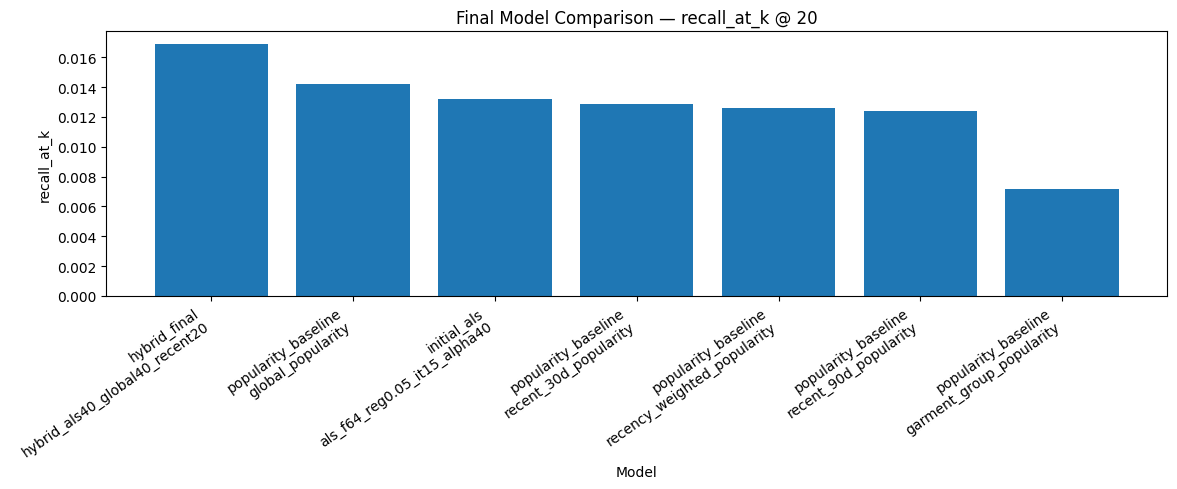

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_comparison_recall_at_k.png


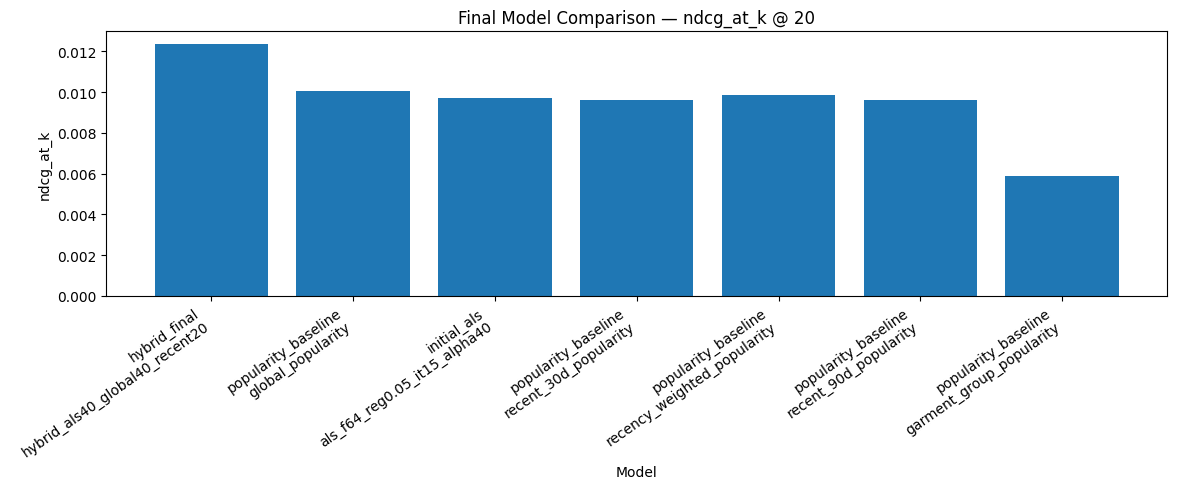

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_comparison_ndcg_at_k.png


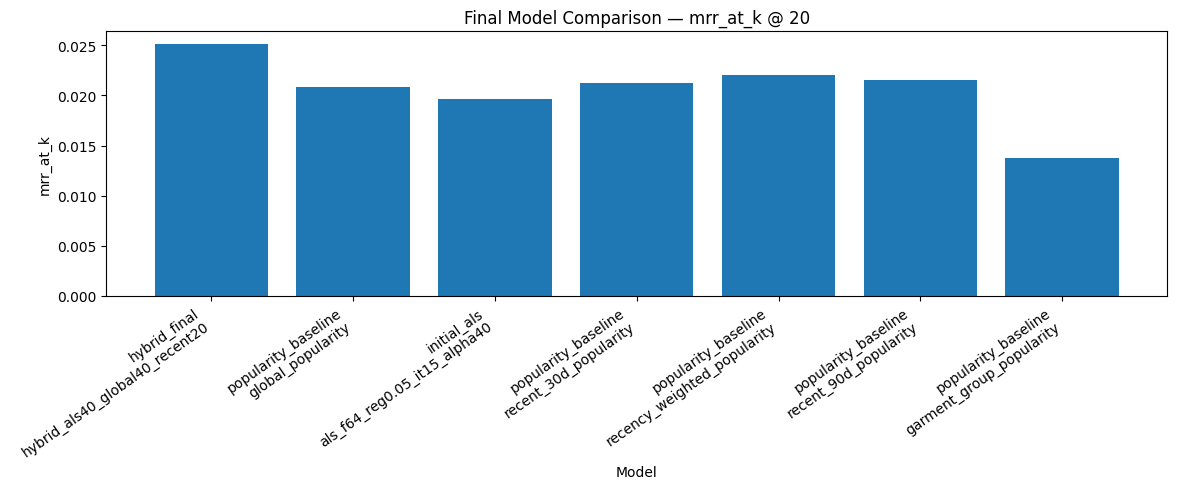

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_comparison_mrr_at_k.png


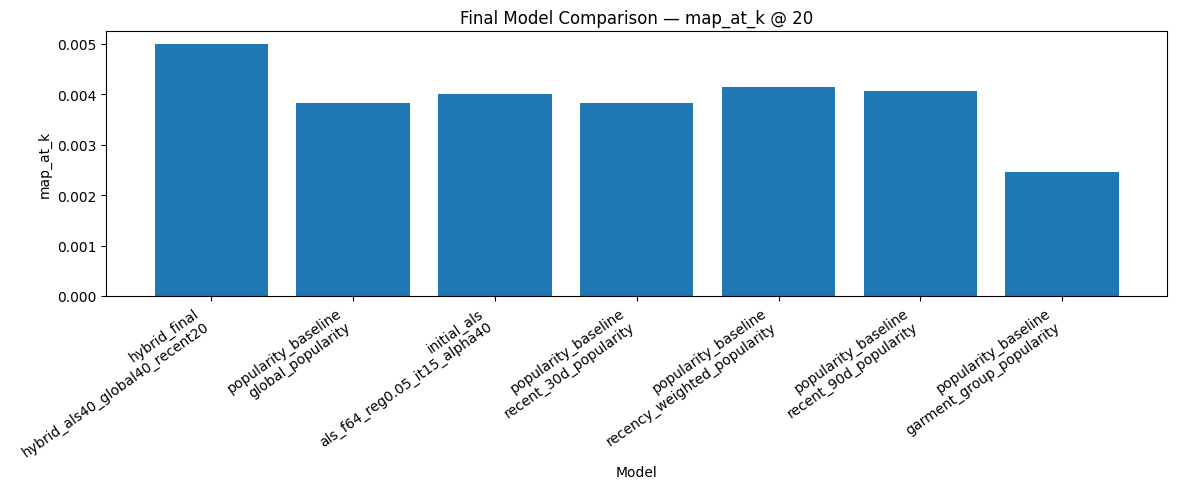

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_comparison_map_at_k.png


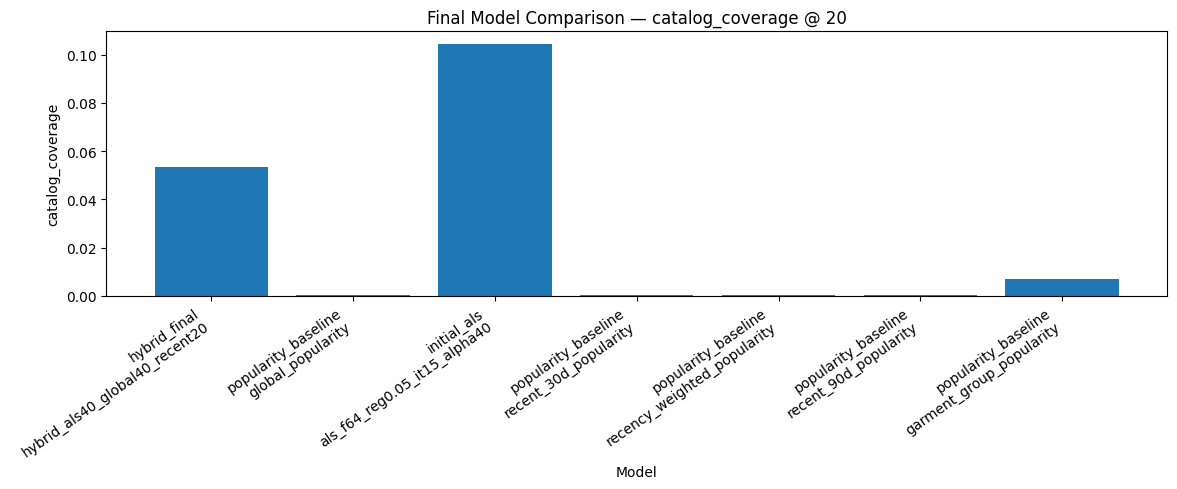

Saved: /kaggle/working/hm-recommender/artifacts/final_model_package/final_comparison_catalog_coverage.png


In [9]:
chart_df = primary_comparison.copy()
chart_df["label"] = chart_df["model_family"].astype(str) + "\n" + chart_df["display_model_name"].astype(str)

if len(chart_df) > 0:
    for metric in ["recall_at_k", "ndcg_at_k", "mrr_at_k", "map_at_k", "catalog_coverage"]:
        plot_df = chart_df[["label", metric]].dropna().copy()
        if len(plot_df) == 0:
            continue
        plt.figure(figsize=(12, 5))
        plt.bar(plot_df["label"], plot_df[metric])
        plt.title(f"Final Model Comparison — {metric} @ {PRIMARY_K}")
        plt.xlabel("Model")
        plt.ylabel(metric)
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        output_path = FINAL_PACKAGE_DIR / f"final_comparison_{metric}.png"
        plt.savefig(output_path, dpi=160)
        plt.show()
        print("Saved:", output_path)
else:
    print("No chart generated because primary comparison table is empty.")

## 7. Final package summary

In [10]:
final_package_summary = {
    "notebook": "07-final-model-packaging-and-comparison.ipynb",
    "purpose": "Create clean final comparison and package final recommender artifacts.",
    "final_package_dir": str(FINAL_PACKAGE_DIR),
    "best_final_model": best_final_model_info.get("final_model_name"),
    "best_final_model_family": best_final_model_info.get("final_model_family"),
    "saved_files": sorted([p.name for p in FINAL_PACKAGE_DIR.glob("*")]),
}

print(json.dumps(final_package_summary, indent=2, default=str))
save_json(final_package_summary, FINAL_PACKAGE_DIR / "final_package_summary.json")

print("Final packaging completed successfully.")

{
  "notebook": "07-final-model-packaging-and-comparison.ipynb",
  "purpose": "Create clean final comparison and package final recommender artifacts.",
  "final_package_dir": "/kaggle/working/hm-recommender/artifacts/final_model_package",
  "best_final_model": "hybrid_als40_global40_recent20",
  "best_final_model_family": "hybrid_final",
  "saved_files": [
    "best_final_model_info.json",
    "best_popularity_model_info.json",
    "copied_artifact_files.json",
    "demo_hybrid_recommendations.parquet",
    "final_comparison_catalog_coverage.png",
    "final_comparison_map_at_k.png",
    "final_comparison_mrr_at_k.png",
    "final_comparison_ndcg_at_k.png",
    "final_comparison_recall_at_k.png",
    "final_hybrid_leaderboard_k20.csv",
    "final_model_comparison_all_rows.csv",
    "final_model_comparison_k20.csv",
    "hybrid_decision_summary.json",
    "hybrid_submission_like_demo.csv",
    "hybrid_tuning_leaderboard_k20.csv",
    "hybrid_vs_popularity_improvement.csv",
    "hybrid_v